# Automating video segmentation the lung area by intergrate Pretrain yolo&SAM 2

This notebook shows how to use SAM 2 for interactive segmentation in videos. It will cover the following:

- adding clicks (or box) on a frame to get and refine _masklets_ (spatio-temporal masks)
- propagating clicks (or box) to get _masklets_ throughout the video
- segmenting and tracking multiple objects at the same time

We use the terms _segment_ or _mask_ to refer to the model prediction for an object on a single frame, and _masklet_ to refer to the spatio-temporal masks across the entire video. 

## Environment Set-up

If running locally using jupyter, first install `segment-anything-2` in your environment using the [installation instructions](https://github.com/facebookresearch/segment-anything-2#installation) in the repository.

If running from Google Colab, set `using_colab=True` below and run the cell. In Colab, be sure to select 'GPU' under 'Edit'->'Notebook Settings'->'Hardware accelerator'. Note that it's recommended to use **A100 or L4 GPUs when running in Colab** (T4 GPUs might also work, but could be slow and might run out of memory in some cases).

In [35]:
import torch
import torchvision
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())
import sys
%pip install opencv-python matplotlib
%pip install git+https://github.com/facebookresearch/segment-anything-2.git

PyTorch version: 2.9.1+cu126
Torchvision version: 0.24.1+cu126
CUDA is available: True
Note: you may need to restart the kernel to use updated packages.
  Cloning https://github.com/facebookresearch/segment-anything-2.git to c:\users\resea\appdata\local\temp\pip-req-build-epim7sq1
  Resolved https://github.com/facebookresearch/segment-anything-2.git to commit 2b90b9f5ceec907a1c18123530e92e794ad901a4
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Note: you may need to restart the kernel to use updated packages.


  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything-2.git 'C:\Users\resea\AppData\Local\Temp\pip-req-build-epim7sq1'


## Set-up

In [36]:
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
import cv2

In [37]:
# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: cuda


In [38]:
import torch
print(f"PyTorch built with CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")


PyTorch built with CUDA: True
Number of GPUs: 1
GPU Name: NVIDIA T1000 8GB


### Loading the SAM 2 video predictor

In [39]:
from sam2.build_sam import build_sam2_video_predictor

sam2_checkpoint = r"F:\Alex-programing\programing\4D_Dynamic_Volume_estimation\sam2_hiera_large.pt"
model_cfg = r"F:\Alex-programing\programing\4D_Dynamic_Volume_estimation\sam2\configs\sam2\sam2_hiera_l.yaml"

predictor = build_sam2_video_predictor(model_cfg, sam2_checkpoint, device=device)

In [40]:
def show_mask(mask, ax, obj_id=None, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        cmap = plt.get_cmap("tab10")
        cmap_idx = 0 if obj_id is None else obj_id
        color = np.array([*cmap(cmap_idx)[:3], 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_binary_mask(mask, ax, obj_id=None, random_color=False):
    # Ensure mask is binary (0 for background, 1 for mask)
    binary_mask = mask.astype(np.uint8)
    # Scale the mask to 255 (0: black, 255: white)
    binary_mask *= 255
    
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        # Use a color from the colormap for the object ID
        cmap = plt.get_cmap("tab10")
        cmap_idx = 0 if obj_id is None else obj_id
        color = np.array([*cmap(cmap_idx)[:3], 0.6])

        # Apply the color to the mask
        h, w = mask.shape[-2:]
        mask_image = binary_mask.reshape(h, w, 1)
        ax.imshow(mask_image)
        # print(mask_image)

def img_binary_mask_with_matplotlib(mask):
    # Ensure the mask is binary (0 for background, 1 for foreground)
    binary_mask = mask.astype(np.uint8)
    
    # Scale the mask to 255 (0: black, 255: white)
    binary_mask *= 255
    
    # Apply the color to the mask
    h, w = mask.shape[-2:]
    mask_image = binary_mask.reshape(h, w, 1)
    
    # Convert to PIL grayscale image and save
    img = mask_image[:, :, 0]
    return img

def show_points(coords, labels, ax, marker_size=200):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)


def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))

#### Select an example video

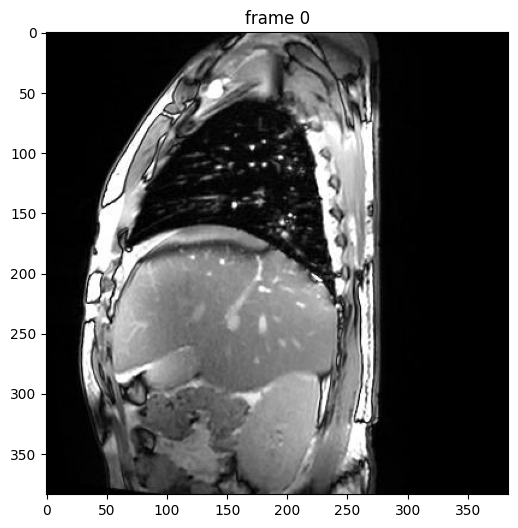

In [41]:
# `video_dir` a directory of JPEG frames with filenames like `<frame_index>.jpg`
video_dir = r"F:\Alex-programing\programing\4D_Dynamic_Volume_estimation\Sample_MRI\Slice_0007"

# scan all the JPEG frame names in this directory
frame_names = [
    p for p in os.listdir(video_dir)
    if os.path.splitext(p)[-1] in [".jpg", ".jpeg", ".JPG", ".JPEG"]
]
frame_names.sort(key=lambda p: int(os.path.splitext(p)[0]))

# take a look the first video frame
frame_idx = 0
plt.figure(figsize=(9, 6))
plt.title(f"frame {frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[frame_idx])))

#### Initialize the inference state

SAM 2 requires stateful inference for interactive video segmentation, so we need to initialize an **inference state** on this video.

During initialization, it loads all the JPEG frames in `video_path` and stores their pixels in `inference_state` (as shown in the progress bar below).

In [42]:
inference_state = predictor.init_state(video_path=video_dir)

frame loading (JPEG): 100%|██████████| 35/35 [00:01<00:00, 31.09it/s]


### Example 2: Segment an object using box prompt

Note: if you have run any previous tracking using this `inference_state`, please reset it first via `reset_state`.

In [43]:
predictor.reset_state(inference_state)

In addition to using clicks as inputs, SAM 2 also supports segmenting and tracking objects in a video via **bounding boxes**.

In the example below, we segment the child on the right using a **box prompt** of (x_min, y_min, x_max, y_max) = (300, 0, 500, 400) on frame 0 as input into the `add_new_points_or_box` API.

In [44]:
from ultralytics import YOLO

import cv2


model_path = r'F:\Alex-programing\programing\4D_Dynamic_Volume_estimation\runs\segment\train34\weights\best.pt'

image_path = os.path.join(video_dir, frame_names[frame_idx])

img = cv2.imread(image_path)
H, W, _ = img.shape

model = YOLO(model_path)

results = model(img)
results[0].show()

for result in results:
    for j, mask in enumerate(result.masks.data):

        mask = mask.cpu().numpy() * 255

        mask = cv2.resize(mask, (W, H))

        cv2.imwrite('./output.png', mask)
for result in results:
    boxes = result.boxes  # Boxes object for bounding box outputs
    for box in boxes:
        # Get coordinates in pixel format [x1, y1, x2, y2] (top-left, bottom-right)
        coordinates = box.xyxy[0].tolist() 
        x1, y1, x2, y2 = [round(x) for x in coordinates]
        
        # Get normalized coordinates [x_center, y_center, width, height] (0-1 range)
        # normalized_coords = box.xywhn[0].tolist()

        # Get confidence score
        confidence = box.conf[0].item()

        # Get class index and name
        class_index = box.cls[0].item()
        class_name = model.names[int(class_index)]
        
        print(f"Object: {class_name}, Confidence: {confidence:.2f}")
        print(f"Coordinates (xyxy): {x1}, {y1}, {x2}, {y2}\n")


0: 512x512 1 lung, 80.4ms
Speed: 6.6ms preprocess, 80.4ms inference, 1.8ms postprocess per image at shape (1, 3, 512, 512)
Object: lung, Confidence: 0.94
Coordinates (xyxy): 78, 62, 231, 192



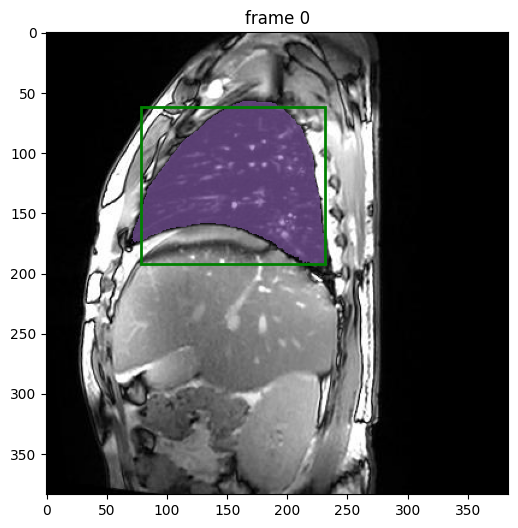

In [45]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 4  # give a unique id to each object we interact with (it can be any integers)

# Let's add a box at (x_min, y_min, x_max, y_max) = (300, 0, 500, 400) to get started
box = np.array(coordinates, dtype=np.float32)
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    box=box,
)

# show the results on the current (interacted) frame
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
show_box(box, plt.gca())
show_mask((out_mask_logits[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_ids[0])

propaganda of mask and saving for processing

propagate in video: 100%|██████████| 35/35 [01:11<00:00,  2.04s/it]
C:\Users\resea\AppData\Local\Temp\ipykernel_14288\1736219939.py:16: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6, 4))


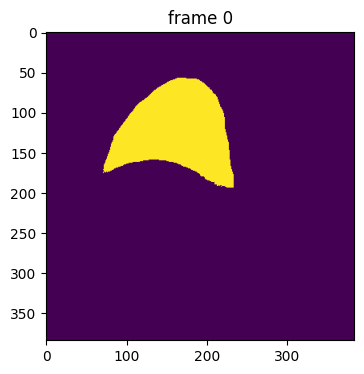

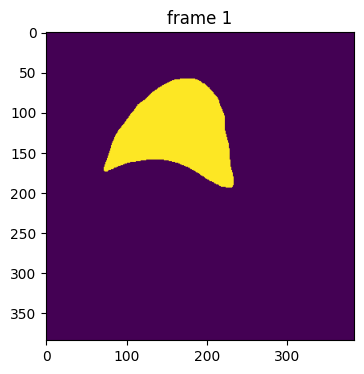

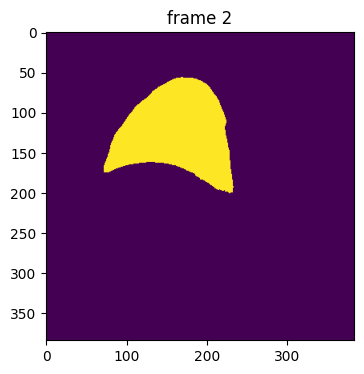

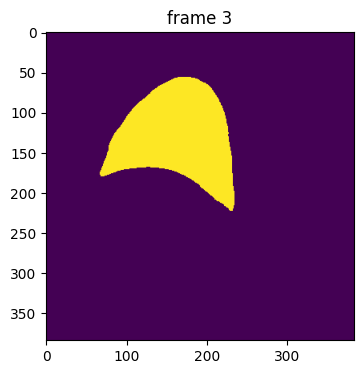

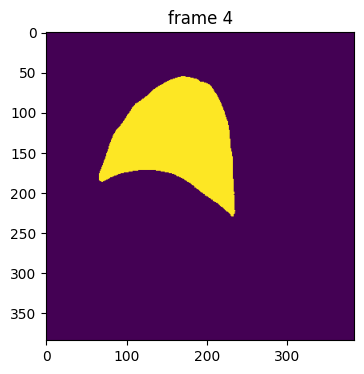

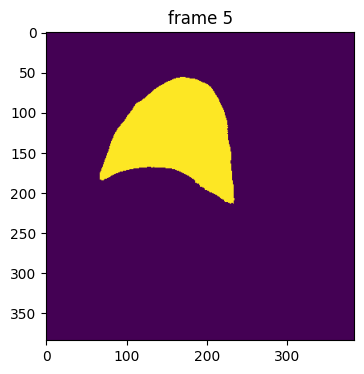

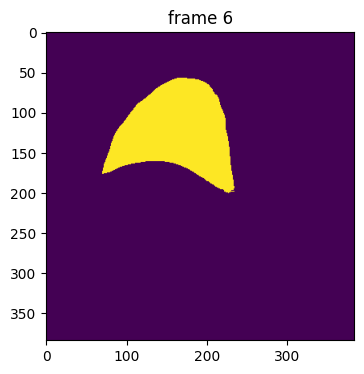

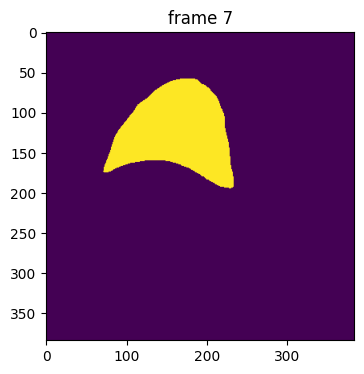

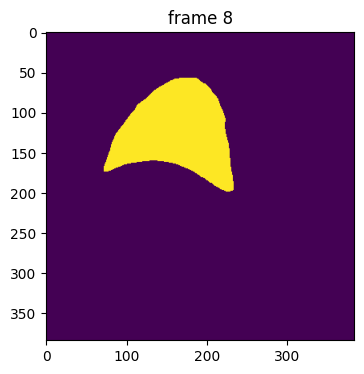

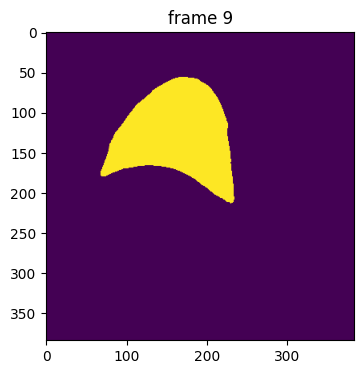

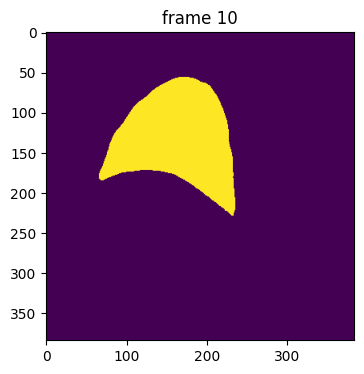

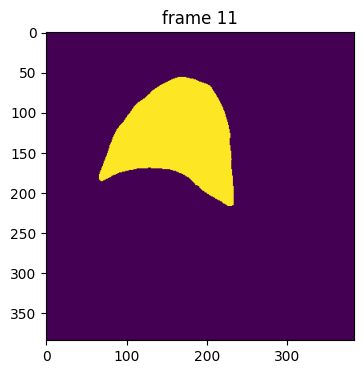

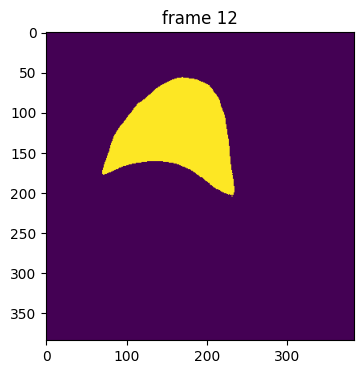

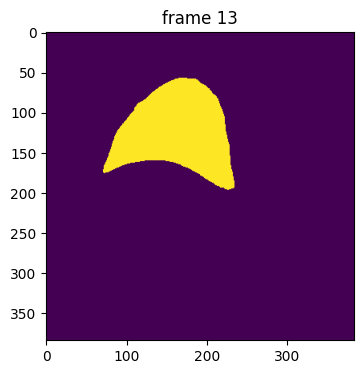

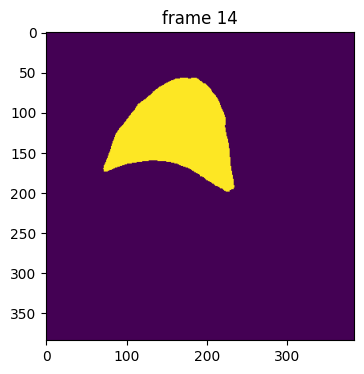

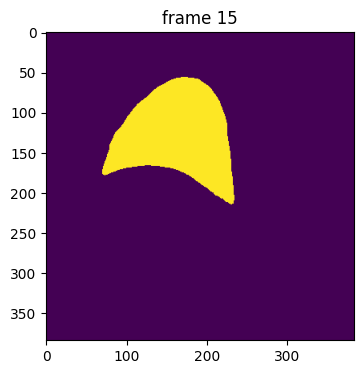

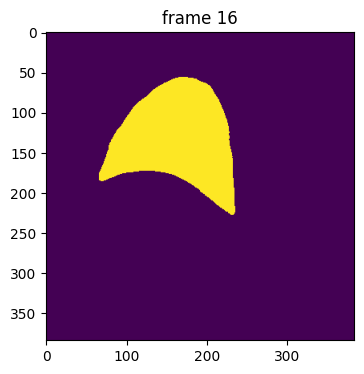

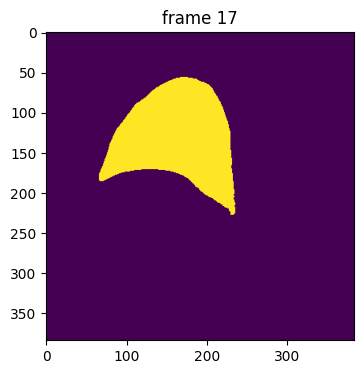

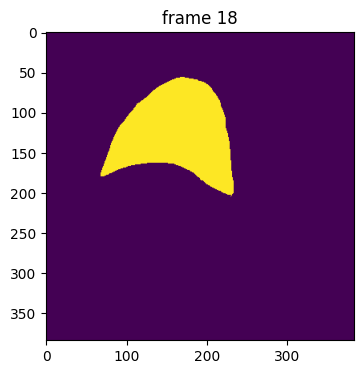

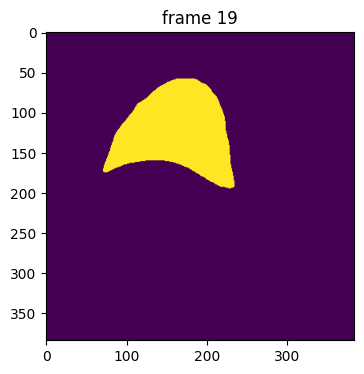

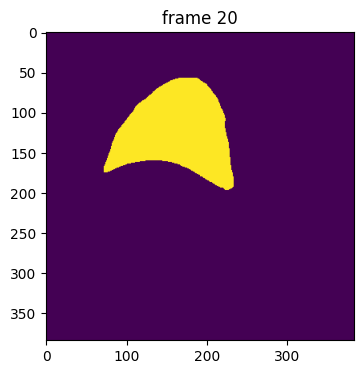

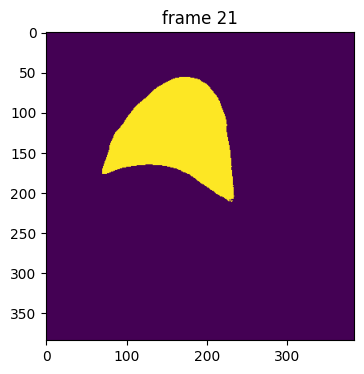

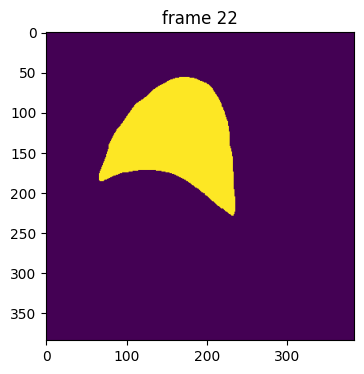

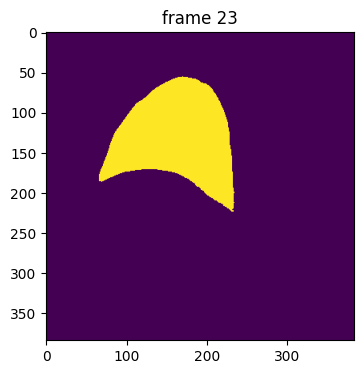

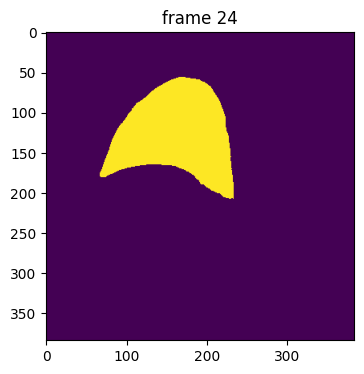

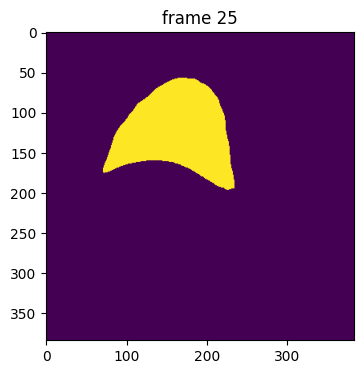

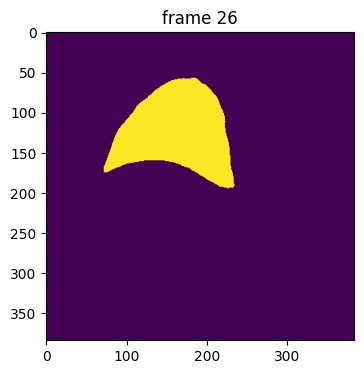

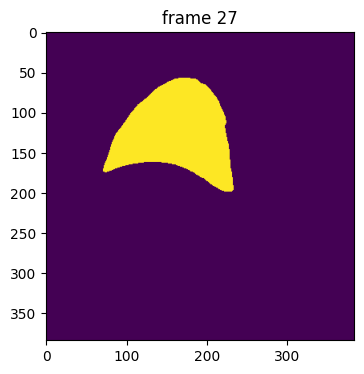

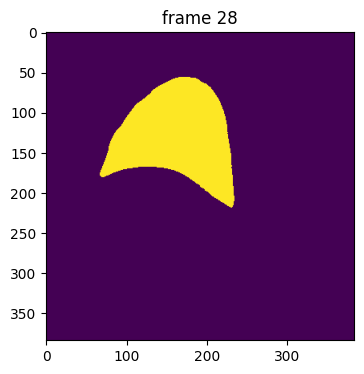

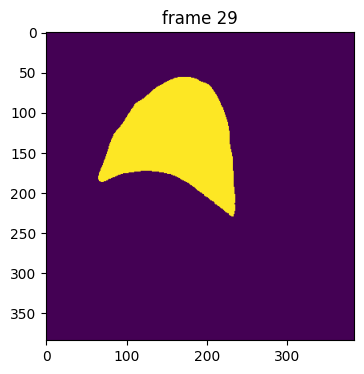

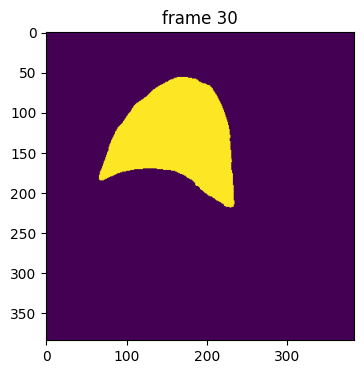

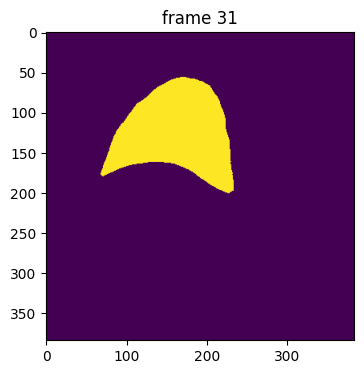

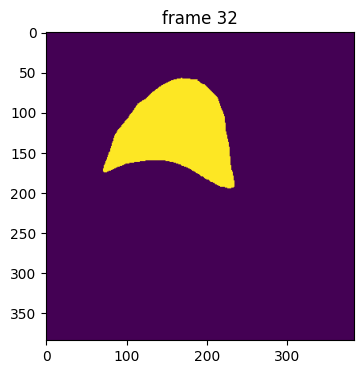

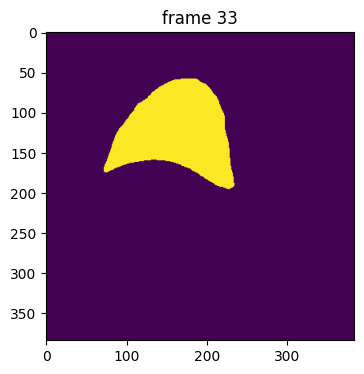

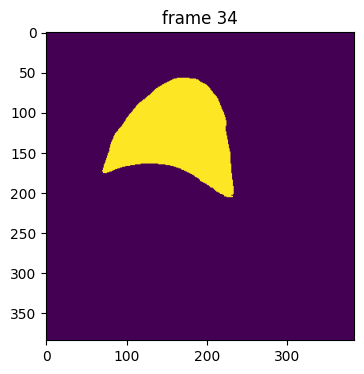

In [46]:
# run propagation throughout the video and collect the results in a dict
video_segments = {}  # video_segments contains the per-frame segmentation results
for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
    video_segments[out_frame_idx] = {
        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(out_obj_ids)
    }

# render the segmentation results every few frames
vis_frame_stride = 1
plt.close("all")
save_path = r"F:\Alex-programing\programing\4D_Dynamic_Volume_estimation\Sample_Mask\Slice_0007"
if not os.path.exists(save_path):
            os.makedirs(save_path)
for out_frame_idx in range(0, len(frame_names), vis_frame_stride):
    plt.figure(figsize=(6, 4))
    plt.title(f"frame {out_frame_idx}")
    save_path_png = os.path.join(f'{save_path}', f'0{out_frame_idx:04d}.jpg')
    frame_source = os.path.join(video_dir, frame_names[out_frame_idx])
    frame = cv2.imread(frame_source , cv2.IMREAD_GRAYSCALE)
    for out_obj_id, out_mask in video_segments[out_frame_idx].items():
        # show_mask(out_mask, plt.gca(), obj_id=out_obj_id)
        show_binary_mask(out_mask, plt.gca(),obj_id=out_obj_id )
        
        img = img_binary_mask_with_matplotlib(out_mask)
        
        img = Image.fromarray(img, mode='L')
        
        img.save(save_path_png)

Then, to get the masklet throughout the entire video, we propagate the prompts using the `propagate_in_video` API.

propagate in video: 100%|██████████| 35/35 [01:13<00:00,  2.10s/it]


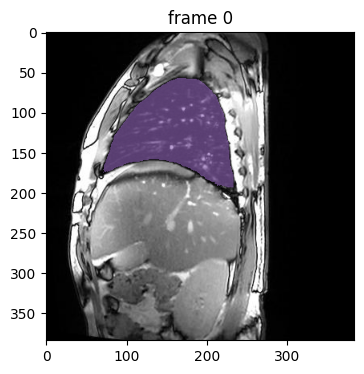

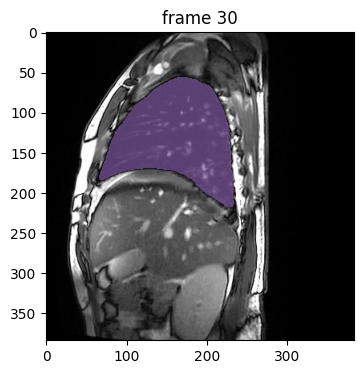

In [47]:
# run propagation throughout the video and collect the results in a dict
video_segments = {}  # video_segments contains the per-frame segmentation results
for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
    video_segments[out_frame_idx] = {
        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(out_obj_ids)
    }

# render the segmentation results every few frames
vis_frame_stride = 30
plt.close("all")
for out_frame_idx in range(0, len(frame_names), vis_frame_stride):
    plt.figure(figsize=(6, 4))
    plt.title(f"frame {out_frame_idx}")
    plt.imshow(Image.open(os.path.join(video_dir, frame_names[out_frame_idx])))
    for out_obj_id, out_mask in video_segments[out_frame_idx].items():
        show_mask(out_mask, plt.gca(), obj_id=out_obj_id)